In [53]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

tra = pd.read_csv(r"D:\pythonfiles\__pycache__\保险预测\train.csv",index_col=0)
tes=pd.read_csv(r"D:\pythonfiles\__pycache__\保险预测\test.csv",index_col=0)

print("数据前五行：\n",tra.head())


数据前五行：
     Gender  Age  Driving_License  Region_Code  Previously_Insured Vehicle_Age  \
id                                                                              
1     Male   44                1         28.0                   0   > 2 Years   
2     Male   76                1          3.0                   0    1-2 Year   
3     Male   47                1         28.0                   0   > 2 Years   
4     Male   21                1         11.0                   1    < 1 Year   
5   Female   29                1         41.0                   1    < 1 Year   

   Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  Response  
id                                                                          
1             Yes         40454.0                  26.0      217         1  
2              No         33536.0                  26.0      183         0  
3             Yes         38294.0                  26.0       27         1  
4              No         28619.0      

列联表：
 Response       0      1
Gender                 
Female    156835  18185
Male      177564  28525


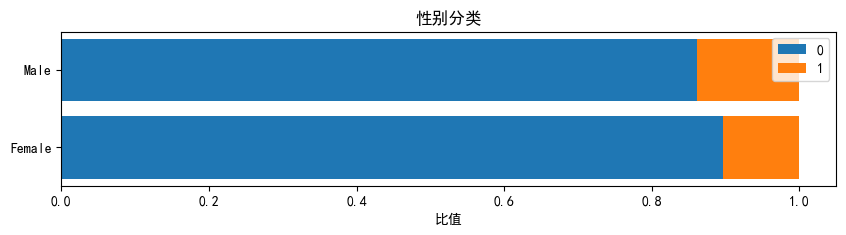

In [26]:
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(tra['Gender'], tra['Response'])
print("列联表：\n", contingency_table)

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=('SimHei','Microsoft YaHei','WenQuanYi Micro Hei')


contingency_table['否']=contingency_table[0]/(contingency_table[0]+contingency_table[1])
contingency_table['是']=contingency_table[1]/(contingency_table[0]+contingency_table[1])

categories=contingency_table.index
group00=contingency_table['否'].values
group01=contingency_table['是'].values
plt.figure(figsize=(10,2))
plt.barh(categories, group00,label='0')
plt.barh(categories, group01,left=group00,label='1')
plt.title('性别分类')
plt.xlabel('比值')
plt.legend()
plt.show()




In [6]:
#卡方检验
chi, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"卡方值: {chi:.4f}, p值: {p_value:.4f}")

卡方值: 1047.7078, p值: 0.0000


列联表：
 Response              0      1
Driving_License               
0                   771     41
1                333628  46669
卡方值: 38.6341, p值: 0.0000


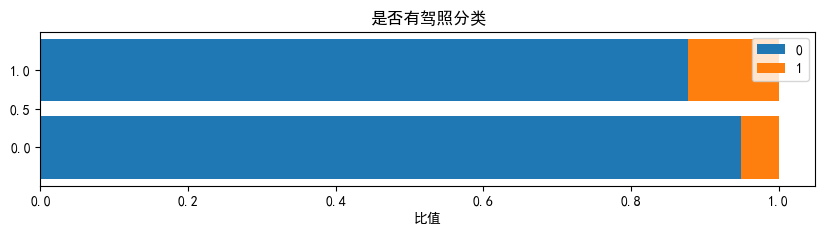

In [27]:
contingency_table1 = pd.crosstab(tra['Driving_License'], tra['Response'])
print("列联表：\n", contingency_table1)
#卡方检验
chi1, p_value1, dof, expected = chi2_contingency(contingency_table1)
print(f"卡方值: {chi1:.4f}, p值: {p_value1:.4f}")
contingency_table1['否']=contingency_table1[0]/(contingency_table1[0]+contingency_table1[1])
contingency_table1['是']=contingency_table1[1]/(contingency_table1[0]+contingency_table1[1])

categories1=contingency_table1.index
group10=contingency_table1['否'].values
group11=contingency_table1['是'].values
plt.figure(figsize=(10,2))
plt.barh(categories1, group10,label='0')
plt.barh(categories1, group11,left=group10,label='1')
plt.title('是否有驾照分类')
plt.xlabel('比值')
plt.legend()
plt.show()

列联表：
 Response         0      1
Region_Code              
0.0           1847    174
1.0            899    109
2.0           3751    287
3.0           8070   1181
4.0           1516    285
5.0           1131    148
6.0           5841    439
7.0           2847    432
8.0          30620   3257
9.0           2848    253
10.0          4111    263
11.0          8191   1041
12.0          2886    312
13.0          3672    364
14.0          4256    422
15.0         12350    958
16.0          1873    134
17.0          2433    184
18.0          4475    678
19.0          1285    250
20.0          1712    223
21.0          3963    303
22.0          1226     83
23.0          1660    300
24.0          2073    342
25.0          2396    107
26.0          2400    187
27.0          2614    209
28.0         86498  19917
29.0          9700   1365
30.0         11291    900
31.0          1763    197
32.0          2548    239
33.0          6894    760
34.0          1538    126
35.0          6077    865
36.0  

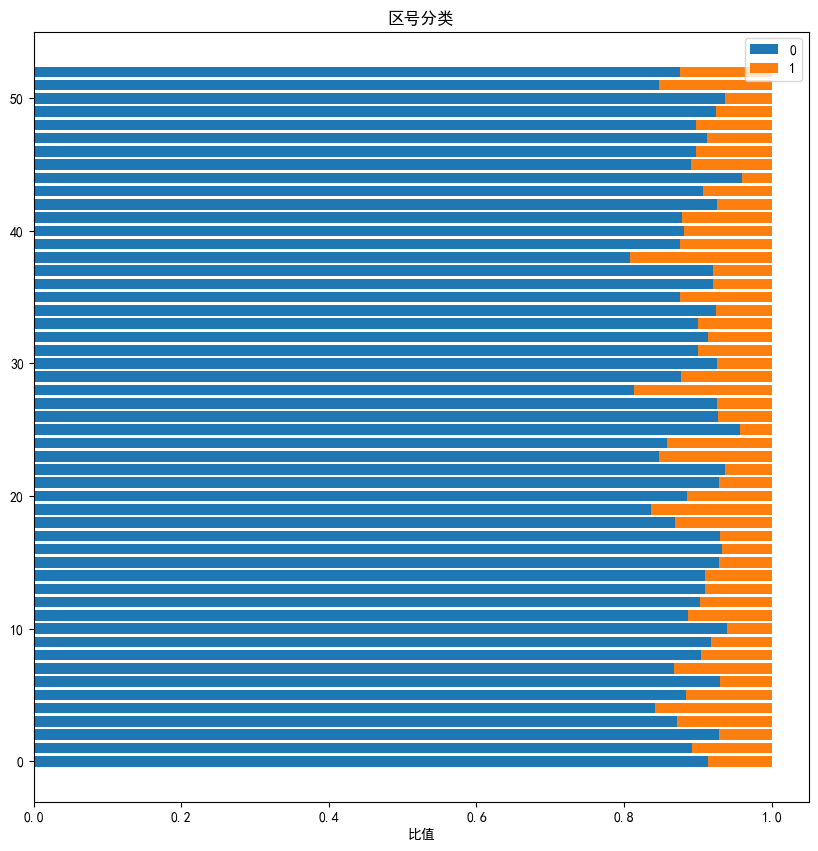

In [28]:
contingency_table2 = pd.crosstab(tra['Region_Code'], tra['Response'])
print("列联表：\n", contingency_table2)
#卡方检验
chi2, p_value2, dof, expected = chi2_contingency(contingency_table2)
print(f"卡方值: {chi2:.4f}, p值: {p_value2:.4f}")

contingency_table2['否']=contingency_table2[0]/(contingency_table2[0]+contingency_table2[1])
contingency_table2['是']=contingency_table2[1]/(contingency_table2[0]+contingency_table2[1])

categories2=contingency_table2.index
group20=contingency_table2['否'].values
group21=contingency_table2['是'].values
plt.figure(figsize=(10,10))
plt.barh(categories2, group20,label='0')
plt.barh(categories2, group21,left=group20,label='1')
plt.title('区号分类')
plt.xlabel('比值')
plt.legend()
plt.show()

列联表：
 Response                 0      1
Previously_Insured               
0                   159929  46552
1                   174470    158
卡方值: 44357.9647, p值: 0.0000


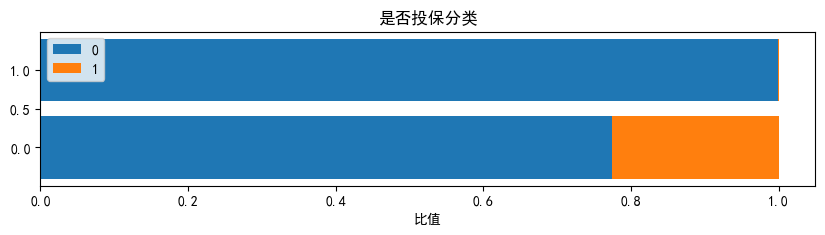

In [31]:
contingency_table3 = pd.crosstab(tra['Previously_Insured'], tra['Response'])
print("列联表：\n", contingency_table3)
#卡方检验
chi3, p_value3, dof, expected = chi2_contingency(contingency_table3)
print(f"卡方值: {chi3:.4f}, p值: {p_value3:.4f}")

contingency_table3['否']=contingency_table3[0]/(contingency_table3[0]+contingency_table3[1])
contingency_table3['是']=contingency_table3[1]/(contingency_table3[0]+contingency_table3[1])

categories3=contingency_table3.index
group30=contingency_table3['否'].values
group31=contingency_table3['是'].values
plt.figure(figsize=(10,2))
plt.barh(categories3, group30,label='0')
plt.barh(categories3, group31,left=group30,label='1')
plt.title('是否投保分类')
plt.xlabel('比值')
plt.legend()
plt.show()

列联表：
 Response          0      1
Vehicle_Age               
1-2 Year     165510  34806
< 1 Year     157584   7202
> 2 Years     11305   4702
卡方值: 18771.8899, p值: 0.0000


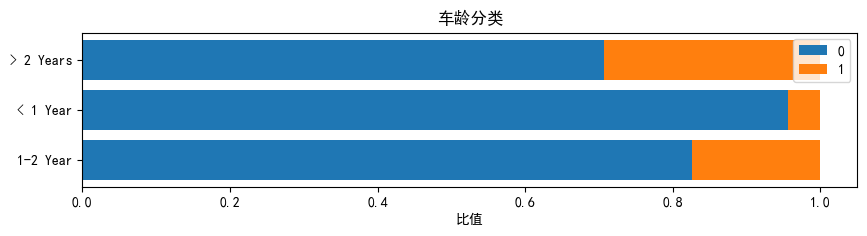

In [32]:
contingency_table4 = pd.crosstab(tra['Vehicle_Age'], tra['Response'])
print("列联表：\n", contingency_table4)
#卡方检验
chi4, p_value4, dof, expected = chi2_contingency(contingency_table4)
print(f"卡方值: {chi4:.4f}, p值: {p_value4:.4f}")

contingency_table4['否']=contingency_table4[0]/(contingency_table4[0]+contingency_table4[1])
contingency_table4['是']=contingency_table4[1]/(contingency_table4[0]+contingency_table4[1])

categories4=contingency_table4.index
group40=contingency_table4['否'].values
group41=contingency_table4['是'].values
plt.figure(figsize=(10,2))
plt.barh(categories4, group40,label='0')
plt.barh(categories4, group41,left=group40,label='1')
plt.title('车龄分类')
plt.xlabel('比值')
plt.legend()
plt.show()


列联表：
 Response             0      1
Vehicle_Damage               
No              187714    982
Yes             146685  45728
卡方值: 47864.7618, p值: 0.0000


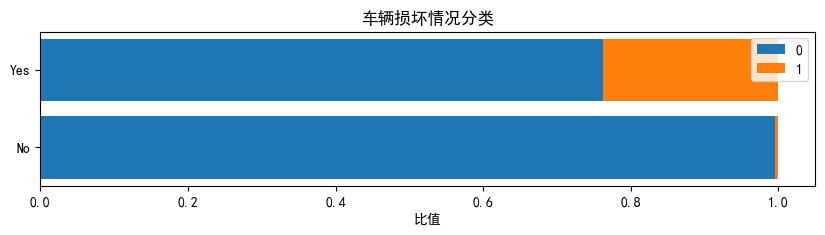

In [34]:
contingency_table5 = pd.crosstab(tra['Vehicle_Damage'], tra['Response'])
print("列联表：\n", contingency_table5)
#卡方检验
chi5, p_value5, dof, expected = chi2_contingency(contingency_table5)
print(f"卡方值: {chi5:.4f}, p值: {p_value5:.4f}")

contingency_table5['否']=contingency_table5[0]/(contingency_table5[0]+contingency_table5[1])
contingency_table5['是']=contingency_table5[1]/(contingency_table5[0]+contingency_table5[1])

categories5=contingency_table5.index
group50=contingency_table5['否'].values
group51=contingency_table5['是'].values
plt.figure(figsize=(10,2))
plt.barh(categories5, group50,label='0')
plt.barh(categories5, group51,left=group50,label='1')
plt.title('车辆损坏情况分类')
plt.xlabel('比值')
plt.legend()
plt.show()

列联表：
 Response                  0     1
Policy_Sales_Channel             
1.0                    1039    35
2.0                       3     1
3.0                     364   159
4.0                     407   102
6.0                       3     0
...                     ...   ...
157.0                  4890  1794
158.0                   357   135
159.0                    50     1
160.0                 21304   475
163.0                  2013   880

[155 rows x 2 columns]
卡方值: 26447.0329, p值: 0.0000


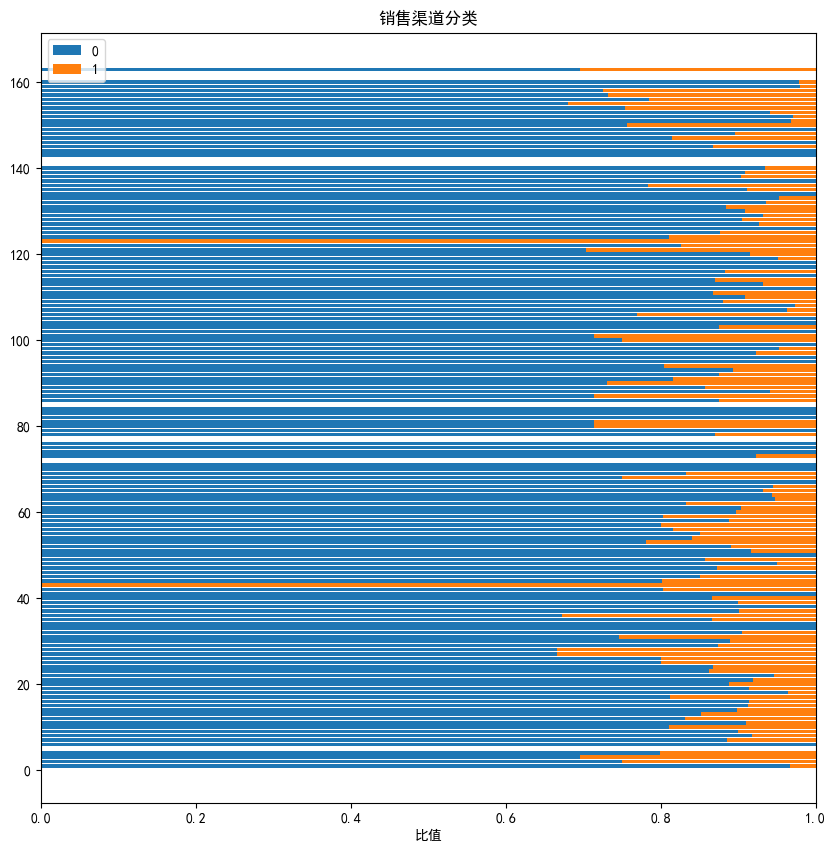

In [35]:
contingency_table6 = pd.crosstab(tra['Policy_Sales_Channel'], tra['Response'])
print("列联表：\n", contingency_table6)
#卡方检验
chi6, p_value6, dof, expected = chi2_contingency(contingency_table6)
print(f"卡方值: {chi6:.4f}, p值: {p_value6:.4f}")

contingency_table6['否']=contingency_table6[0]/(contingency_table6[0]+contingency_table6[1])
contingency_table6['是']=contingency_table6[1]/(contingency_table6[0]+contingency_table6[1])

categories6=contingency_table6.index
group60=contingency_table6['否'].values
group61=contingency_table6['是'].values
plt.figure(figsize=(10,10))
plt.barh(categories6, group60,label='0')
plt.barh(categories6, group61,left=group60,label='1')
plt.title('销售渠道分类')
plt.xlabel('比值')
plt.legend()
plt.show()

In [ ]:
x1 = tra['Age']
x2 = tra['Annual_Premium']
x3 = tra['Vintage']

y = tra['Response']  # 需确保y为0/1编码

# 计算点二列相关系数和p值
r1, pvalue1 = pointbiserialr(x1, y)
print(f"点二列相关系数: {r1:.4f}, p值: {pvalue1:.4f}")
r2, pvalue2 = pointbiserialr(x2, y)
print(f"点二列相关系数: {r2:.4f}, p值: {pvalue2:.4f}")
r3, pvalue3 = pointbiserialr(x3, y)
print(f"点二列相关系数: {r3:.4f}, p值: {pvalue3:.4f}")


点二列相关系数: 0.1111, p值: 0.0000
点二列相关系数: 0.0226, p值: 0.0000
点二列相关系数: -0.0011, p值: 0.5167


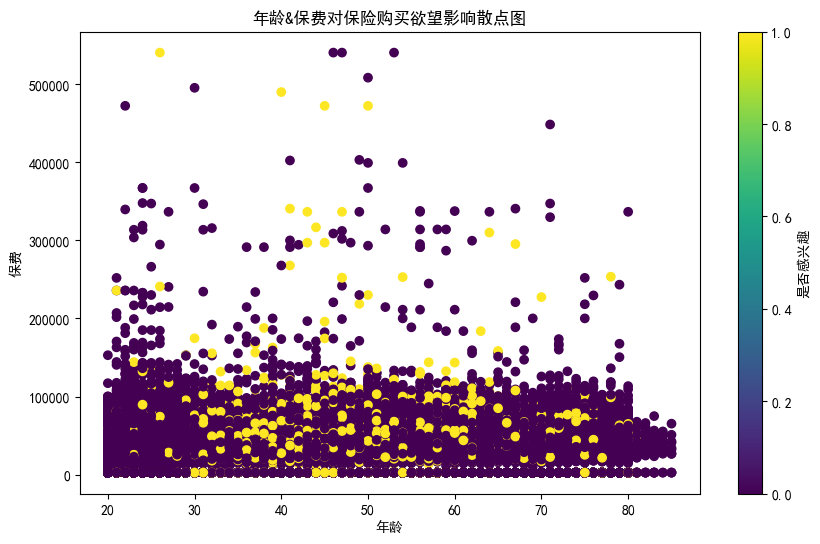

In [39]:
plt.figure(figsize=(10,6))
plt.scatter(x1,x2,c=y,cmap='viridis')
plt.xlabel('年龄')
plt.ylabel('保费')
plt.title('年龄&保费对保险购买欲望影响散点图')
plt.colorbar(label='是否感兴趣')
plt.show()

In [40]:
tra.describe()

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [54]:
#从上述分析可得，Vintage相关性小、Region_Code，Policy_Sales_Channel	两分类变量分类数过多，不易解读，可做删除
#处理；Annual_Premium右偏分布，有部分数据过大，需处理异常值； 

tra=tra.drop(['Region_Code','Policy_Sales_Channel','Vintage'],axis=1)

#使用盖帽法处理数据
f_max=tra['Annual_Premium'].mean()+3*tra['Annual_Premium'].std()
f_min=tra['Annual_Premium'].mean()-3*tra['Annual_Premium'].std()

tra.loc[tra['Annual_Premium']>f_max,'Annual_Premium']=f_max
tra.loc[tra['Annual_Premium']<f_min,'Annual_Premium']=f_min

#对测试集处理
tes=tes.drop(['Region_Code','Policy_Sales_Channel','Vintage'],axis=1)

#使用盖帽法处理数据

tes.loc[tes['Annual_Premium']>f_max,'Annual_Premium']=f_max
tes.loc[tes['Annual_Premium']<f_min,'Annual_Premium']=f_min

tra['Gender']=tra['Gender'].map({'Male':0,'Female':1})
tra['Vehicle_Age']=tra['Vehicle_Age'].map({'< 1 Year':0,'1-2 Year':1,'> 2 Years':2})
tra['Vehicle_Damage']=tra['Vehicle_Damage'].map({'No':0,'Yes':1})

tes['Gender']=tes['Gender'].map({'Male':0,'Female':1})
tes['Vehicle_Age']=tes['Vehicle_Age'].map({'< 1 Year':0,'1-2 Year':1,'> 2 Years':2})
tes['Vehicle_Damage']=tes['Vehicle_Damage'].map({'No':0,'Yes':1})

print(tra.head())
print(tes.head())


    Gender  Age  Driving_License  Previously_Insured  Vehicle_Age  \
id                                                                  
1        0   44                1                   0            2   
2        0   76                1                   0            1   
3        0   47                1                   0            2   
4        0   21                1                   1            0   
5        1   29                1                   1            0   

    Vehicle_Damage  Annual_Premium  Response  
id                                            
1                1         40454.0         1  
2                0         33536.0         0  
3                1         38294.0         1  
4                0         28619.0         0  
5                0         27496.0         0  
        Gender  Age  Driving_License  Previously_Insured  Vehicle_Age  \
id                                                                      
381110       0   25                1     

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 划分训练集和测试集（分层抽样，保证类别比例一致）
X = tra.drop('Response', axis=1)
y = tra['Response']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify=y保证类别比例
)
# 应用欠采样
rus = RandomUnderSampler(sampling_strategy=0.3333,random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"欠采样后正样本比例：{y_train_resampled.sum()/len(y_train_resampled):.2%}")



#将数据标准化
scaler=MinMaxScaler()

X_trainsca=pd.DataFrame(scaler.fit_transform(X_train_resampled),columns=X_train.columns)
X_valsca=pd.DataFrame(scaler.fit_transform(X_val),columns=X_val.columns)

X_textsca=pd.DataFrame(scaler.fit_transform(tes),columns=tes.columns)

print(X_trainsca.head(10))


欠采样后正样本比例：25.00%
   Gender       Age  Driving_License  Previously_Insured  Vehicle_Age  \
0     1.0  0.061538              1.0                 1.0          0.0   
1     1.0  0.030769              1.0                 1.0          0.0   
2     0.0  0.123077              1.0                 1.0          0.0   
3     1.0  0.323077              1.0                 0.0          0.5   
4     1.0  0.015385              1.0                 0.0          0.0   
5     0.0  0.153846              1.0                 1.0          0.0   
6     1.0  0.184615              1.0                 0.0          0.5   
7     1.0  0.292308              1.0                 1.0          0.5   
8     0.0  0.446154              1.0                 0.0          0.5   
9     1.0  0.307692              1.0                 1.0          0.5   

   Vehicle_Damage  Annual_Premium  
0             0.0        0.364818  
1             0.0        0.266934  
2             0.0        0.317177  
3             1.0        0.370122  

    Gender       Age  Driving_License  Previously_Insured  Vehicle_Age  \
0      1.0  0.062500              1.0                 1.0          0.0   
1      1.0  0.031250              1.0                 1.0          0.0   
2      0.0  0.125000              1.0                 1.0          0.0   
3      1.0  0.328125              1.0                 0.0          0.5   
4      1.0  0.015625              1.0                 0.0          0.0   
5      0.0  0.156250              1.0                 1.0          0.0   
6      1.0  0.187500              1.0                 0.0          0.5   
7      1.0  0.296875              1.0                 1.0          0.5   
8      0.0  0.453125              1.0                 0.0          0.5   
9      1.0  0.312500              1.0                 1.0          0.5   
10     0.0  0.062500              1.0                 1.0          0.0   
11     0.0  0.296875              1.0                 0.0          1.0   
12     0.0  0.656250              1.0 

In [78]:
class_weights = {0: len(y) / (2 * (y == 0).sum()), 1: len(y) / (2 * (y == 1).sum())}

model = LogisticRegression(class_weight=class_weights)

# 拟合模型
model.fit(X_trainsca, y_train_resampled)
print("\n模型训练完成！")


模型训练完成！


In [75]:
print(y_val.shape)

(76222,)


In [80]:
# 测试集预测
y_pred = model.predict(X_valsca)
y_prob = model.predict_proba(X_valsca)[:,1]  # 获取预测概率

# 评估指标
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 计算关键指标（pos_label=1表示关注正类/少数类）
recall = recall_score(y_val, y_pred, pos_label=1)  # 正类召回率（找到所有正样本的比例）
f1 = f1_score(y_val, y_pred, pos_label=1)  # F1分数（平衡召回率和精确率）
auc = roc_auc_score(y_val, y_prob)

print(f"正类召回率（Recall）: {recall:.4f}")
print(f"正类F1分数: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print("\n分类报告（Classification Report）：\n", classification_report(y_val, y_pred))
print("\n混淆矩阵（Confusion Matrix）：\n", confusion_matrix(y_val, y_pred))






正类召回率（Recall）: 0.9792
正类F1分数: 0.3974
AUC-ROC: 0.8326

分类报告（Classification Report）：
               precision    recall  f1-score   support

           0       1.00      0.59      0.74     66880
           1       0.25      0.98      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222


混淆矩阵（Confusion Matrix）：
 [[39333 27547]
 [  194  9148]]


In [82]:
#由以上分析可得：此模型预估可排除（39333+194）/76222=52% 的负类样本，需重点关注的正类预估样品中
#准确率为25%，正类召回率为98%


y_text=model.predict(X_textsca)


sample=pd.read_csv(r"D:\pythonfiles\__pycache__\保险预测\sample_submission.csv",index_col=0)
sample['Response']=y_text

print(sample.head())

        Response
id              
381110         0
381111         1
381112         1
381113         0
381114         0


In [91]:

class_weights1 = {0: 1, 1: 1}

model1 = LogisticRegression(class_weight=class_weights1)

# 拟合模型
model1.fit(X_trainsca, y_train_resampled)

# 测试集预测
y_pred1 = model1.predict(X_valsca)
y_prob1 = model1.predict_proba(X_valsca)[:,1]  # 获取预测概率

# 计算关键指标（pos_label=1表示关注正类/少数类）
recall1 = recall_score(y_val, y_pred1, pos_label=1)  # 正类召回率（找到所有正样本的比例）
f11 = f1_score(y_val, y_pred1, pos_label=1)  # F1分数（平衡召回率和精确率）
auc1 = roc_auc_score(y_val, y_prob1)

print(f"正类召回率（Recall）: {recall1:.4f}")
print(f"正类F1分数: {f11:.4f}")
print(f"AUC-ROC: {auc1:.4f}")
print("\n分类报告（Classification Report）：\n", classification_report(y_val, y_pred1))
print("\n混淆矩阵（Confusion Matrix）：\n", confusion_matrix(y_val, y_pred1))

正类召回率（Recall）: 0.2095
正类F1分数: 0.2548
AUC-ROC: 0.8327

分类报告（Classification Report）：
               precision    recall  f1-score   support

           0       0.89      0.94      0.92     66880
           1       0.33      0.21      0.25      9342

    accuracy                           0.85     76222
   macro avg       0.61      0.57      0.59     76222
weighted avg       0.82      0.85      0.84     76222


混淆矩阵（Confusion Matrix）：
 [[62818  4062]
 [ 7385  1957]]


In [ ]:
#当0/1比重相当时预测为1的群体也仅有33%购买欲望，然而召回率仅有21%，此模型无太多实际意义

sample.to_csv('sample_prediction_result.csv', index=1, encoding='utf-8-sig')


In [ ]:

sample.describe()


#重点关注预测结果为1的群体为优质群体，有购买欲望的占比约25%
#预测结果为0的群体可能需要其余刺激，有购买欲望的占比仅约0.5%

,Response
count,127037.000000
mean,0.479711
std,0.499590
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000
